In [195]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm


In [196]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [197]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [198]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [199]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 223.12it/s]


In [200]:
batch_size = 64
beta = 0
learning_rate = 1e-2
num_epochs = 120
channels = 1
latent_dim = 64

# Comment:
# Need to use bigger latent dimension. Bigger than 16. Wider latent dimension,
# the more information is preserved after matrix transformations
# If latent dimension = 16, than noisy outputs from encoder

# num_embeddings = 256 
LOG_EVERY = 10


In [201]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [202]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [203]:
event_train = events_train[:SELECTED_EVENTS][0]

In [204]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [205]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0], std=[1])    
])

event_dataset = PixelPatchesDataset(event_train, transform)

# Training data prepearation
train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Test data preparation
# TODO: apply after the training examples are good
events_test_loaders = []
for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [206]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    # recon_loss = F.mse_loss(
    #     recon_x, 
    #     x, 
    #     reduction="sum"
    # ) / x.size(0)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    
    # KL_divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [207]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        self.z_log_var = torch.clamp(z_log_var, min=-4, max=1)
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var

In [208]:
model = VAE(
    hidden_channels=32, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/120: 100%|██████████| 248/248 [00:00<00:00, 553.63it/s, Loss=107] 


Epoch [1/120] Average Loss: 206.4322
Before compression
Before: (64, 8, 8)


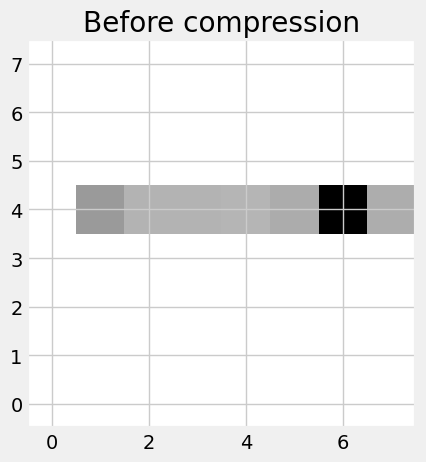

mu: mean=-0.0813, std=2.1471 | logvar: mean=-3.5952, std=0.8706
Loss statistics:

After: (1, 8, 8)
After compression


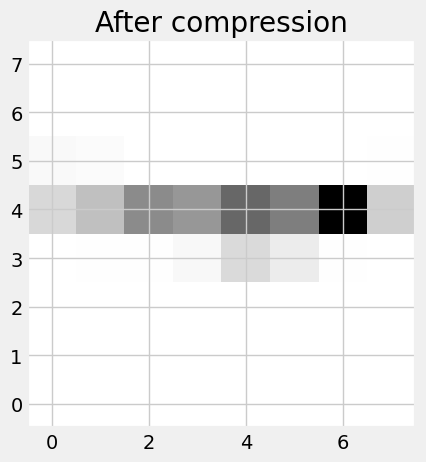

Epoch 2/120: 100%|██████████| 248/248 [00:00<00:00, 571.77it/s, Loss=101] 


Epoch [2/120] Average Loss: 145.0450


Epoch 3/120: 100%|██████████| 248/248 [00:00<00:00, 582.50it/s, Loss=97.6]


Epoch [3/120] Average Loss: 136.8618


Epoch 4/120: 100%|██████████| 248/248 [00:00<00:00, 560.59it/s, Loss=96.6]


...

Epoch [9/120] Average Loss: 126.2052


Epoch 10/120: 100%|██████████| 248/248 [00:00<00:00, 558.50it/s, Loss=96.8]


Epoch [10/120] Average Loss: 125.6635


Epoch 11/120: 100%|██████████| 248/248 [00:00<00:00, 545.90it/s, Loss=95]  


Epoch [11/120] Average Loss: 125.4766
Before compression
Before: (64, 8, 8)


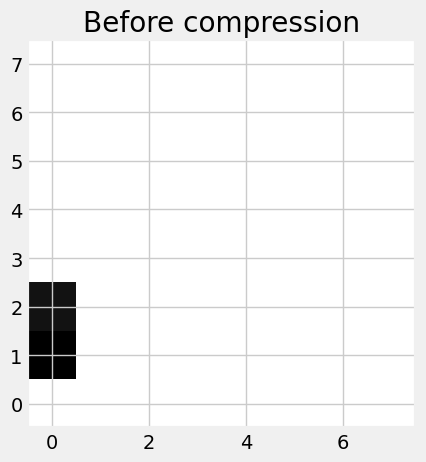

mu: mean=-0.0200, std=4.1115 | logvar: mean=-3.9815, std=0.1422
Loss statistics:

After: (1, 8, 8)
After compression


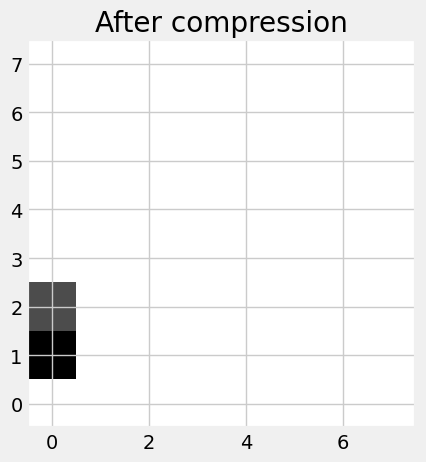

Epoch 12/120: 100%|██████████| 248/248 [00:00<00:00, 578.10it/s, Loss=95.2]


Epoch [12/120] Average Loss: 124.6606


Epoch 13/120: 100%|██████████| 248/248 [00:00<00:00, 567.50it/s, Loss=95.2]


Epoch [13/120] Average Loss: 124.3874


Epoch 14/120: 100%|██████████| 248/248 [00:00<00:00, 557.93it/s, Loss=94.3]


...

Epoch [19/120] Average Loss: 122.1749


Epoch 20/120: 100%|██████████| 248/248 [00:00<00:00, 559.43it/s, Loss=93]  


Epoch [20/120] Average Loss: 121.6384


Epoch 21/120: 100%|██████████| 248/248 [00:00<00:00, 572.16it/s, Loss=92.6]


Epoch [21/120] Average Loss: 121.1649
Before compression
Before: (64, 8, 8)


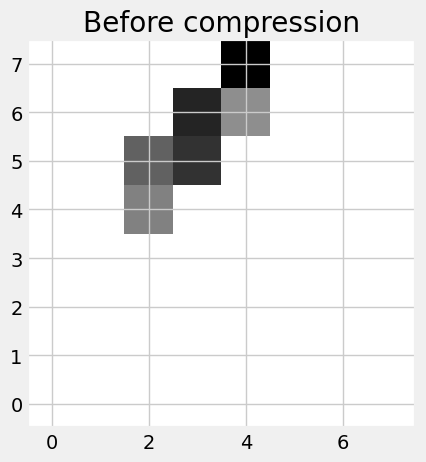

mu: mean=-0.1048, std=4.6340 | logvar: mean=-3.9819, std=0.1263
Loss statistics:

After: (1, 8, 8)
After compression


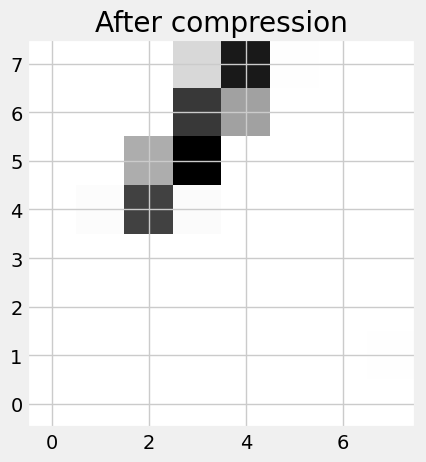

Epoch 22/120: 100%|██████████| 248/248 [00:00<00:00, 573.54it/s, Loss=91.6]


Epoch [22/120] Average Loss: 121.2607


Epoch 23/120: 100%|██████████| 248/248 [00:00<00:00, 569.87it/s, Loss=91.2]


Epoch [23/120] Average Loss: 120.9271


Epoch 24/120: 100%|██████████| 248/248 [00:00<00:00, 581.67it/s, Loss=91.1]


...

Epoch [29/120] Average Loss: 119.5966


Epoch 30/120: 100%|██████████| 248/248 [00:00<00:00, 602.41it/s, Loss=89.6]


Epoch [30/120] Average Loss: 119.2807


Epoch 31/120: 100%|██████████| 248/248 [00:00<00:00, 608.51it/s, Loss=90.5]


Epoch [31/120] Average Loss: 119.0474
Before compression
Before: (64, 8, 8)


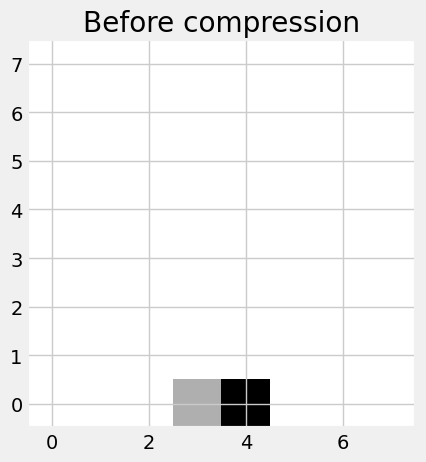

mu: mean=-0.0988, std=5.0803 | logvar: mean=-3.9858, std=0.1129
Loss statistics:

After: (1, 8, 8)
After compression


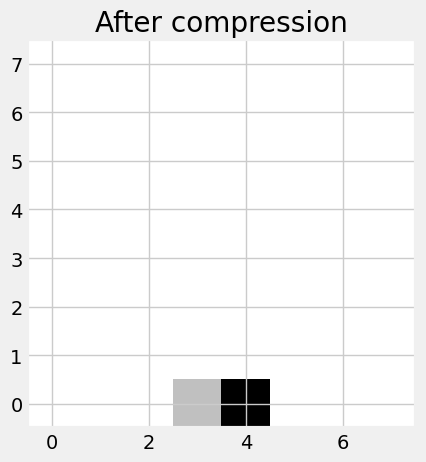

Epoch 32/120: 100%|██████████| 248/248 [00:00<00:00, 587.04it/s, Loss=90.5]


Epoch [32/120] Average Loss: 118.9865


Epoch 33/120: 100%|██████████| 248/248 [00:00<00:00, 549.89it/s, Loss=90.7]


Epoch [33/120] Average Loss: 118.9216


Epoch 34/120: 100%|██████████| 248/248 [00:00<00:00, 603.41it/s, Loss=90.3]


...

Epoch [39/120] Average Loss: 118.1376


Epoch 40/120: 100%|██████████| 248/248 [00:00<00:00, 568.68it/s, Loss=90.8]


Epoch [40/120] Average Loss: 117.8206


Epoch 41/120: 100%|██████████| 248/248 [00:00<00:00, 559.15it/s, Loss=89.1]


Epoch [41/120] Average Loss: 117.6988
Before compression
Before: (64, 8, 8)


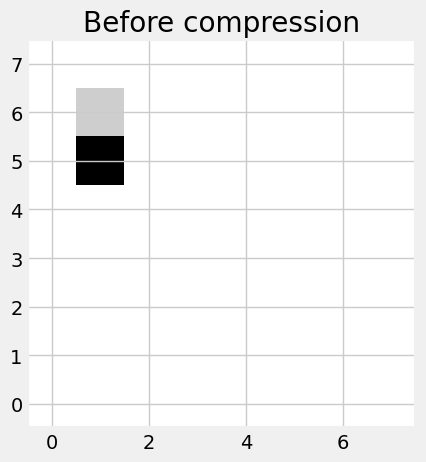

mu: mean=-0.1804, std=5.2366 | logvar: mean=-3.9688, std=0.3195
Loss statistics:

After: (1, 8, 8)
After compression


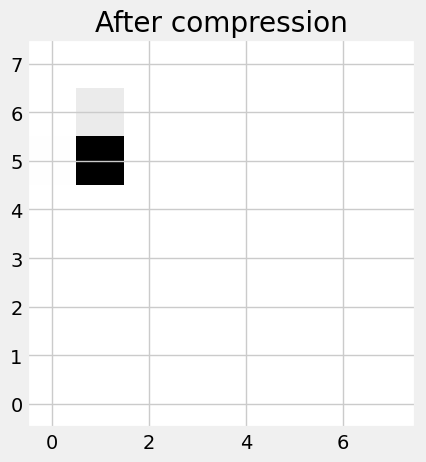

Epoch 42/120: 100%|██████████| 248/248 [00:00<00:00, 557.74it/s, Loss=91.4]


Epoch [42/120] Average Loss: 117.4340


Epoch 43/120: 100%|██████████| 248/248 [00:00<00:00, 568.13it/s, Loss=90.5]


Epoch [43/120] Average Loss: 117.5232


Epoch 44/120: 100%|██████████| 248/248 [00:00<00:00, 571.32it/s, Loss=90.4]


...

Epoch [49/120] Average Loss: 116.9249


Epoch 50/120: 100%|██████████| 248/248 [00:00<00:00, 568.22it/s, Loss=89.3]


Epoch [50/120] Average Loss: 116.8881


Epoch 51/120: 100%|██████████| 248/248 [00:00<00:00, 559.48it/s, Loss=88.9]


Epoch [51/120] Average Loss: 116.9438
Before compression
Before: (64, 8, 8)


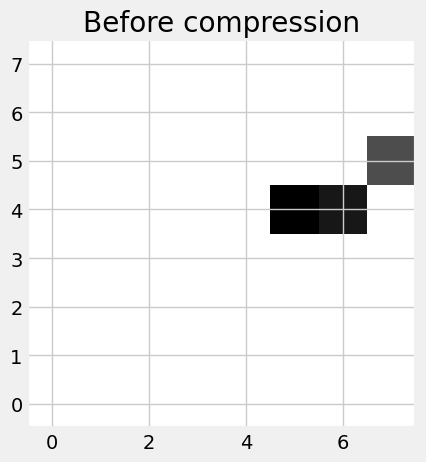

mu: mean=-0.1983, std=5.5432 | logvar: mean=-3.9935, std=0.0750
Loss statistics:

After: (1, 8, 8)
After compression


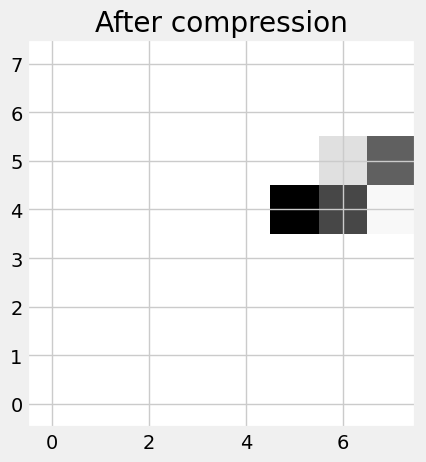

Epoch 52/120: 100%|██████████| 248/248 [00:00<00:00, 548.00it/s, Loss=89.6]


Epoch [52/120] Average Loss: 116.4871


Epoch 53/120: 100%|██████████| 248/248 [00:00<00:00, 560.22it/s, Loss=88.3]


Epoch [53/120] Average Loss: 116.2924


Epoch 54/120: 100%|██████████| 248/248 [00:00<00:00, 561.51it/s, Loss=88.9]


...

Epoch [59/120] Average Loss: 115.7037


Epoch 60/120: 100%|██████████| 248/248 [00:00<00:00, 575.28it/s, Loss=89.5]


Epoch [60/120] Average Loss: 115.5678


Epoch 61/120: 100%|██████████| 248/248 [00:00<00:00, 570.09it/s, Loss=88.6]


Epoch [61/120] Average Loss: 115.4546
Before compression
Before: (64, 8, 8)


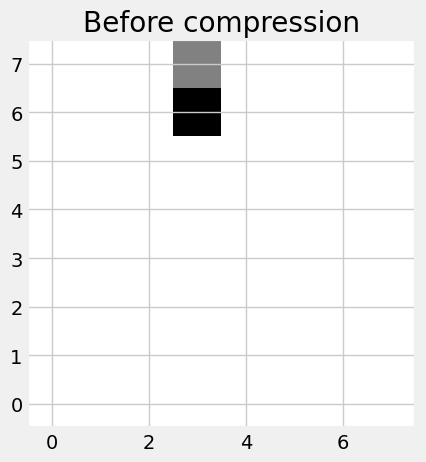

mu: mean=-0.2904, std=5.7477 | logvar: mean=-3.9880, std=0.1080
Loss statistics:

After: (1, 8, 8)
After compression


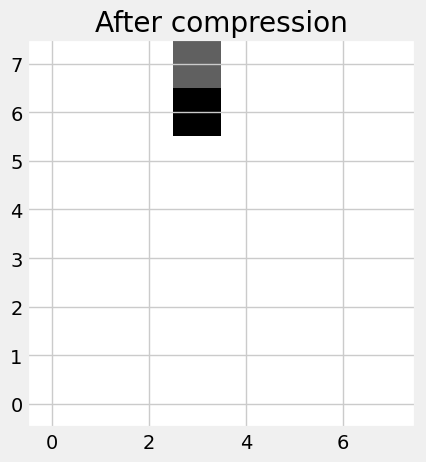

Epoch 62/120: 100%|██████████| 248/248 [00:00<00:00, 570.50it/s, Loss=88.3]


Epoch [62/120] Average Loss: 115.3947


Epoch 63/120: 100%|██████████| 248/248 [00:00<00:00, 573.14it/s, Loss=89.6]


Epoch [63/120] Average Loss: 115.2099


Epoch 64/120: 100%|██████████| 248/248 [00:00<00:00, 539.71it/s, Loss=89]  


...

Epoch [69/120] Average Loss: 114.8672


Epoch 70/120: 100%|██████████| 248/248 [00:00<00:00, 571.70it/s, Loss=87.8]


Epoch [70/120] Average Loss: 114.7905


Epoch 71/120: 100%|██████████| 248/248 [00:00<00:00, 562.25it/s, Loss=89.8]


Epoch [71/120] Average Loss: 114.6881
Before compression
Before: (64, 8, 8)


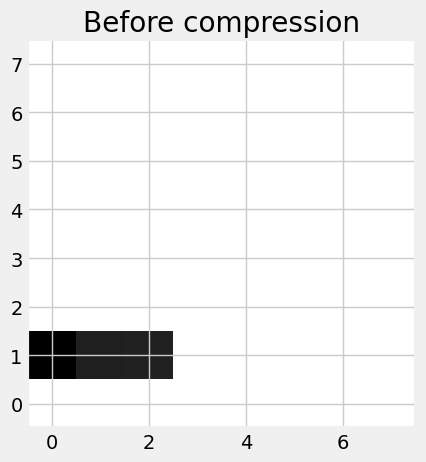

mu: mean=-0.3418, std=5.8717 | logvar: mean=-3.9950, std=0.0630
Loss statistics:

After: (1, 8, 8)
After compression


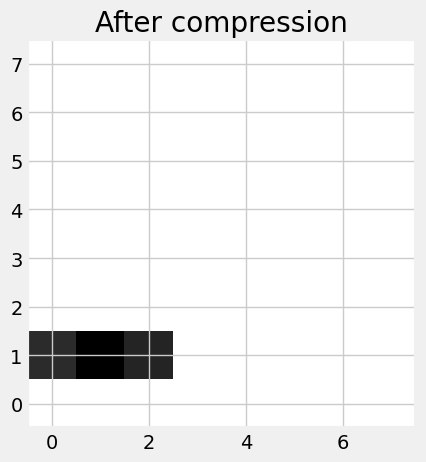

Epoch 72/120: 100%|██████████| 248/248 [00:00<00:00, 560.03it/s, Loss=88.8]


Epoch [72/120] Average Loss: 114.6777


Epoch 73/120: 100%|██████████| 248/248 [00:00<00:00, 570.26it/s, Loss=88.6]


Epoch [73/120] Average Loss: 114.3503


Epoch 74/120: 100%|██████████| 248/248 [00:00<00:00, 581.93it/s, Loss=88.1]


...

Epoch [79/120] Average Loss: 114.1958


Epoch 80/120: 100%|██████████| 248/248 [00:00<00:00, 561.34it/s, Loss=88]  


Epoch [80/120] Average Loss: 114.0688


Epoch 81/120: 100%|██████████| 248/248 [00:00<00:00, 556.81it/s, Loss=88.6]


Epoch [81/120] Average Loss: 113.8231
Before compression
Before: (64, 8, 8)


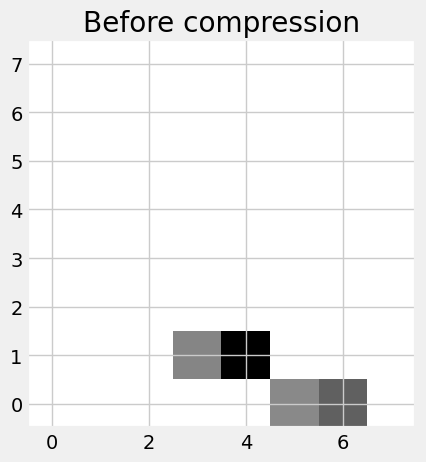

mu: mean=-0.2110, std=5.9966 | logvar: mean=-3.9757, std=0.1959
Loss statistics:

After: (1, 8, 8)
After compression


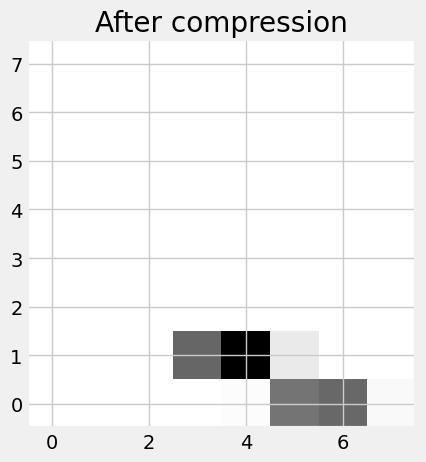

Epoch 82/120: 100%|██████████| 248/248 [00:00<00:00, 557.44it/s, Loss=88.3]


Epoch [82/120] Average Loss: 113.7659


Epoch 83/120: 100%|██████████| 248/248 [00:00<00:00, 570.79it/s, Loss=89]  


Epoch [83/120] Average Loss: 113.8158


Epoch 84/120: 100%|██████████| 248/248 [00:00<00:00, 569.70it/s, Loss=89]  


...

Epoch [89/120] Average Loss: 114.1322


Epoch 90/120: 100%|██████████| 248/248 [00:00<00:00, 591.35it/s, Loss=88.2]


Epoch [90/120] Average Loss: 113.9254


Epoch 91/120: 100%|██████████| 248/248 [00:00<00:00, 586.68it/s, Loss=89.4]


Epoch [91/120] Average Loss: 113.6925
Before compression
Before: (64, 8, 8)


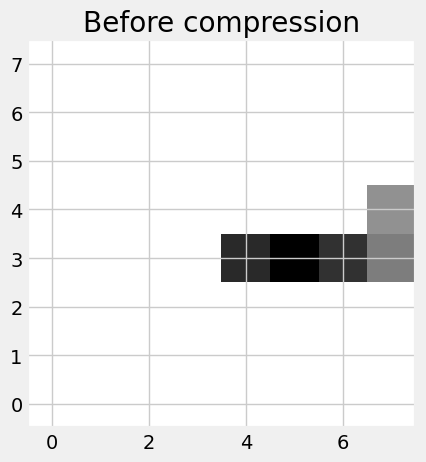

mu: mean=-0.1066, std=6.1415 | logvar: mean=-3.9906, std=0.0945
Loss statistics:

After: (1, 8, 8)
After compression


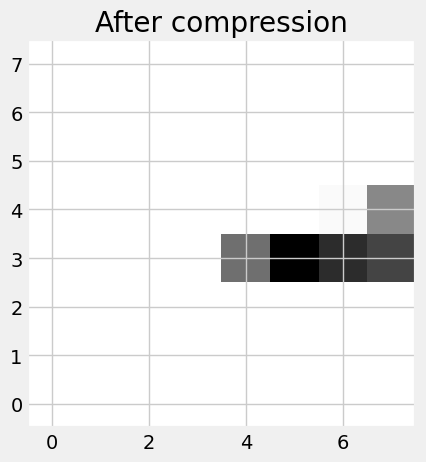

Epoch 92/120: 100%|██████████| 248/248 [00:00<00:00, 568.89it/s, Loss=89.5]


Epoch [92/120] Average Loss: 113.5237


Epoch 93/120: 100%|██████████| 248/248 [00:00<00:00, 562.86it/s, Loss=88.4]


Epoch [93/120] Average Loss: 113.3294


Epoch 94/120: 100%|██████████| 248/248 [00:00<00:00, 572.36it/s, Loss=88]  


...

Epoch [99/120] Average Loss: 112.9585


Epoch 100/120: 100%|██████████| 248/248 [00:00<00:00, 581.37it/s, Loss=87.6]


Epoch [100/120] Average Loss: 112.8772


Epoch 101/120: 100%|██████████| 248/248 [00:00<00:00, 568.89it/s, Loss=86.9]


Epoch [101/120] Average Loss: 112.7380
Before compression
Before: (64, 8, 8)


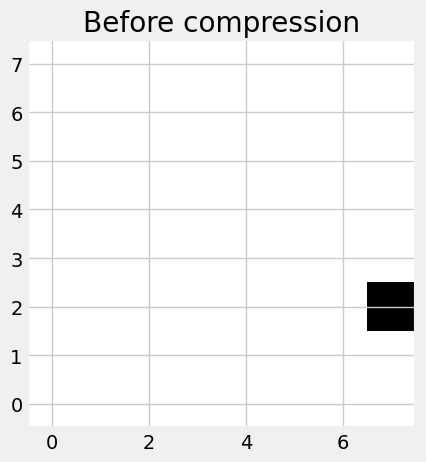

mu: mean=-0.2843, std=6.3120 | logvar: mean=-3.9956, std=0.0707
Loss statistics:

After: (1, 8, 8)
After compression


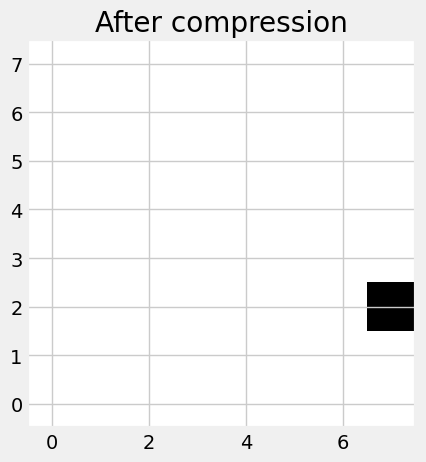

Epoch 102/120: 100%|██████████| 248/248 [00:00<00:00, 577.45it/s, Loss=87.4]


Epoch [102/120] Average Loss: 112.6700


Epoch 103/120: 100%|██████████| 248/248 [00:00<00:00, 584.21it/s, Loss=87]  


Epoch [103/120] Average Loss: 112.6530


Epoch 104/120: 100%|██████████| 248/248 [00:00<00:00, 579.25it/s, Loss=87.5]


...

Epoch [109/120] Average Loss: 112.8974


Epoch 110/120: 100%|██████████| 248/248 [00:00<00:00, 560.07it/s, Loss=87.6]


Epoch [110/120] Average Loss: 113.0228


Epoch 111/120: 100%|██████████| 248/248 [00:00<00:00, 571.78it/s, Loss=87.2]


Epoch [111/120] Average Loss: 113.2552
Before compression
Before: (64, 8, 8)


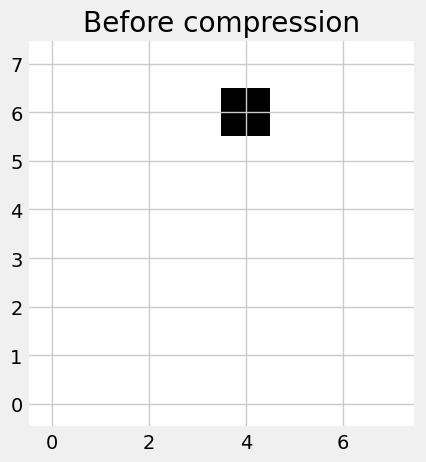

mu: mean=-0.1247, std=6.3901 | logvar: mean=-3.9922, std=0.0863
Loss statistics:

After: (1, 8, 8)
After compression


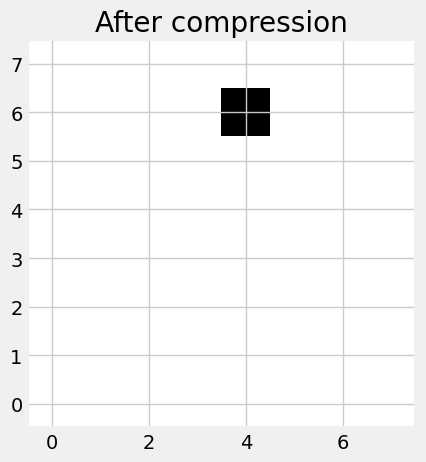

Epoch 112/120: 100%|██████████| 248/248 [00:00<00:00, 573.07it/s, Loss=86.7]


Epoch [112/120] Average Loss: 113.3435


Epoch 113/120: 100%|██████████| 248/248 [00:00<00:00, 559.35it/s, Loss=87.2]


Epoch [113/120] Average Loss: 112.6972


Epoch 114/120: 100%|██████████| 248/248 [00:00<00:00, 559.46it/s, Loss=87.3]


...

Epoch [118/120] Average Loss: 112.2745


Epoch 119/120: 100%|██████████| 248/248 [00:00<00:00, 568.31it/s, Loss=86.7]


Epoch [119/120] Average Loss: 112.1948


Epoch 120/120: 100%|██████████| 248/248 [00:00<00:00, 569.36it/s, Loss=86.2]

Epoch [120/120] Average Loss: 112.1526


In [209]:
average_loss = []
patches_before = []
patches_after = []

patch_test_cursor = iter(events_test_loaders[0])
model.train()

for epoch in range(num_epochs):
    train_loss = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        
        # Adding some randomness for regulating the small noisy areas
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        
        X_adcs = X_adcs.to(device)
        
    
        (
            recon_patch, 
            mu,
            logvar 
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    average_loss.append(avg_loss)
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            print(f"Before: {patch_test_ts.shape}")            
            plot_patch(patch_test_ts[0], "Before compression")
            
            patches_before.append(patch_test_ts[0])
            
            (
                recon_patch, 
                mu,
                logvar 
            ) = model(patch_test)
            
            print(
                f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
            )
            
            print("Loss statistics:")
            print(
                f"recon={recon_loss.item():.4f}, "
                f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
                f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
            )
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            plot_patch(recon_patch_np[0], "After compression")
            
            patches_after.append(recon_patch_np[0])
        

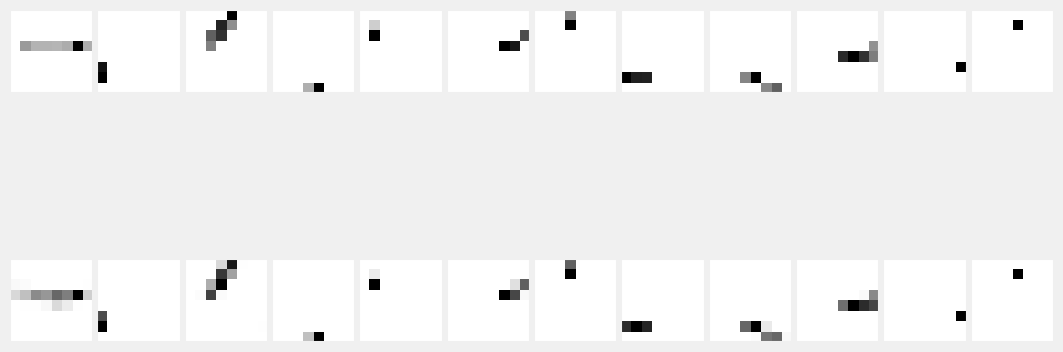

In [210]:
image_rows = [
    patches_before,
    patches_after
]
cols = len(image_rows[0])
rows = len(image_rows)

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows):
    for j in range(cols):
        ax = axes[i, j]
        ax.imshow(image_rows[i][j], cmap='gist_yarg', origin='lower')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [211]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 3.0741677284240723
encoder.1.weight 0.5609720349311829
encoder.1.bias 0.5731907486915588
encoder.3.weight 0.5634425282478333
encoder.4.weight 0.5528889894485474
encoder.4.bias 0.5091114640235901
encoder.6.weight 0.47298792004585266
encoder.7.weight 0.6094596982002258
encoder.7.bias 0.704789936542511
fc_mean.weight 0.46281978487968445
fc_mean.bias 0.07252418249845505
fc_log_var.weight 0.0011049716267734766
fc_log_var.bias 0.0002908249734900892
decoder.0.weight 0.3767865002155304
decoder.1.weight 0.632344126701355
decoder.1.bias 0.5687092542648315
decoder.3.weight 0.8373792767524719
decoder.4.weight 1.1870722770690918
decoder.4.bias 1.7910000085830688
decoder.6.weight 2.5552432537078857


/tmp/ipykernel_2970954/1764288248.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VAE, Average loss values over epochs


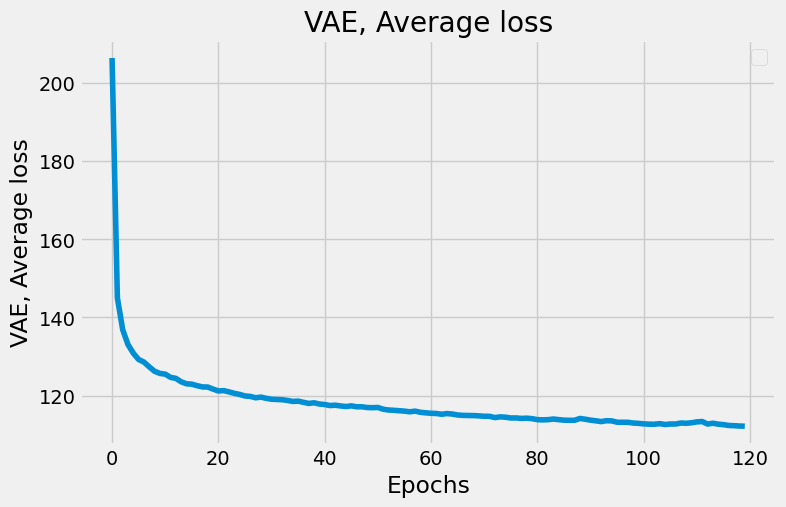

In [212]:
# display loss values
plot_metric_results(
    y_values=average_loss, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [213]:
print(f"mu = {model.z_log_mean.mean().item()}")
print(f"logvar = {model.z_log_var.std().item()}")

mu = -0.2324613332748413
logvar = 0.03123299777507782
